In [6]:
import torch
from torch import nn
net = nn.Sequential(nn.Linear(4, 8),
                    nn.ReLU(),
                    nn.Linear(8, 1))
X = torch.rand(size=(2, 4))
net(X)

tensor([[0.1292],
        [0.0118]], grad_fn=<AddmmBackward0>)

In [7]:
print(net[0].state_dict())
print(net[1].state_dict())
print(net[2].state_dict())

OrderedDict([('weight', tensor([[ 0.3604,  0.4241, -0.4463, -0.2281],
        [ 0.4775,  0.0018, -0.1572,  0.1299],
        [ 0.3991,  0.0743,  0.4293, -0.3868],
        [-0.3414,  0.2077,  0.3830, -0.0974],
        [-0.3232, -0.0516,  0.1248, -0.0021],
        [ 0.0410,  0.2141, -0.2225, -0.3317],
        [ 0.3280,  0.1050,  0.2569, -0.1118],
        [ 0.4830, -0.4167, -0.2536, -0.2990]])), ('bias', tensor([-0.2301, -0.1209, -0.0428,  0.2630, -0.2066, -0.3951, -0.0229,  0.4515]))])
OrderedDict()
OrderedDict([('weight', tensor([[ 0.2575, -0.1110,  0.1384,  0.1635, -0.0557, -0.1669, -0.0329, -0.2414]])), ('bias', tensor([0.0615]))])


In [8]:
print(type(net[2].bias))
print(net[2].bias)
print(net[2].bias.data)

<class 'torch.nn.parameter.Parameter'>
Parameter containing:
tensor([0.0615], requires_grad=True)
tensor([0.0615])


In [11]:
print(net[2].weight.grad)
print(net[2].weight.grad == None)

None
True


In [14]:
print(*[(name, param.shape) for name, param in net[0].named_parameters()])
print(*[(name, param.shape) for name, param in net.named_parameters()])

# P1 = *[(name, param.shape) for name, param in net[0].named_parameters()] is wrong

('weight', torch.Size([8, 4])) ('bias', torch.Size([8]))
('0.weight', torch.Size([8, 4])) ('0.bias', torch.Size([8])) ('2.weight', torch.Size([1, 8])) ('2.bias', torch.Size([1]))


In [18]:
print(net.state_dict())
net.state_dict()['2.bias'].data

OrderedDict([('0.weight', tensor([[ 0.3604,  0.4241, -0.4463, -0.2281],
        [ 0.4775,  0.0018, -0.1572,  0.1299],
        [ 0.3991,  0.0743,  0.4293, -0.3868],
        [-0.3414,  0.2077,  0.3830, -0.0974],
        [-0.3232, -0.0516,  0.1248, -0.0021],
        [ 0.0410,  0.2141, -0.2225, -0.3317],
        [ 0.3280,  0.1050,  0.2569, -0.1118],
        [ 0.4830, -0.4167, -0.2536, -0.2990]])), ('0.bias', tensor([-0.2301, -0.1209, -0.0428,  0.2630, -0.2066, -0.3951, -0.0229,  0.4515])), ('2.weight', tensor([[ 0.2575, -0.1110,  0.1384,  0.1635, -0.0557, -0.1669, -0.0329, -0.2414]])), ('2.bias', tensor([0.0615]))])


tensor([0.0615])

In [27]:
def block1():
    return nn.Sequential(nn.Linear(4, 8), nn.ReLU(),
                         nn.Linear(8, 4), nn.ReLU())

def block2():
    net = nn.Sequential()
    # print(net)
    # print(net.state_dict())
    for i in range(4):
        net.add_module(f'YJM_block{i}', block1())
    return net

rgnet = nn.Sequential(block2(), nn.Linear(4, 1))
rgnet(X)

tensor([[-0.5494],
        [-0.5495]], grad_fn=<AddmmBackward0>)

In [26]:
print(rgnet)

Sequential(
  (0): Sequential(
    (YJM_block0): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=4, bias=True)
      (3): ReLU()
    )
    (YJM_block1): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=4, bias=True)
      (3): ReLU()
    )
    (YJM_block2): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=4, bias=True)
      (3): ReLU()
    )
    (YJM_block3): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=4, bias=True)
      (3): ReLU()
    )
  )
  (1): Linear(in_features=4, out_features=1, bias=True)
)


In [28]:
rgnet[0][2][2].bias.data

tensor([ 0.3019,  0.0225,  0.3324, -0.1092])

In [32]:
# Parameter initialization
def init_normal(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, mean = 0, std = 0.01)
        nn.init.zeros_(m.bias)

net.apply(init_normal)
net[0].weight.data[0], net[0].bias.data[0]

(tensor([-0.0146,  0.0116, -0.0034,  0.0093]), tensor(0.))

In [36]:
def init_constant(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 1)
        nn.init.zeros_(m.bias)
net.apply(init_constant)
net[0].weight.data[0], net[0].bias.data[0]

(tensor([1., 1., 1., 1.]), tensor(0.))

In [42]:
def init_xavier(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
def init_42(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 42)

print(net)
net[0].apply(init_xavier)
net[2].apply(init_42)
print(net.state_dict())
print(net.state_dict()['0.weight'].data[0])
print(net.state_dict()['2.weight'].data)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
OrderedDict([('0.weight', tensor([[ 0.2880,  0.0156, -0.3304, -0.5627],
        [ 0.5391, -0.4869,  0.5546, -0.6695],
        [ 0.2423, -0.1721,  0.2504, -0.2534],
        [-0.4042,  0.4536,  0.4402, -0.4451],
        [-0.2346, -0.5286, -0.3509, -0.3065],
        [-0.1654,  0.3409, -0.5104,  0.6131],
        [-0.0512, -0.0976,  0.0872,  0.4352],
        [-0.5482,  0.6504, -0.0942, -0.0912]])), ('0.bias', tensor([0., 0., 0., 0., 0., 0., 0., 0.])), ('2.weight', tensor([[42., 42., 42., 42., 42., 42., 42., 42.]])), ('2.bias', tensor([0.]))])
tensor([ 0.2880,  0.0156, -0.3304, -0.5627])
tensor([[42., 42., 42., 42., 42., 42., 42., 42.]])


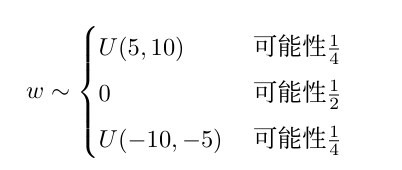

In [44]:
# Custom initialization
def my_init(m):
    if type(m) == nn.Linear:
        print("Init", *[(name, param.shape)
                        for name, param in m.named_parameters()][0])
        nn.init.uniform_(m.weight,-10, 10)
        m.weight.data *= m.weight.data.abs() >= 5

net.apply(my_init)
net[0].weight[:2]

Init weight torch.Size([8, 4])
Init weight torch.Size([1, 8])


tensor([[ 0.0000,  7.2398, -7.2764,  0.0000],
        [ 0.0000,  0.0000,  9.5136,  7.8461]], grad_fn=<SliceBackward0>)

In [45]:
net[0].weight.data[:] += 1
net[0].weight.data[0, 0] = 42
net[0].weight.data[0]

tensor([42.0000,  8.2398, -6.2764,  1.0000])

In [51]:
# Dense Layer = Fully Conected Layer, FC layer

shared = nn.Linear(8, 8)
net = nn.Sequential(nn.Linear(4, 8),
                    nn.ReLU(),
                    shared,
                    nn.ReLU(),
                    shared,
                    nn.ReLU(),
                    nn.Linear(8, 1))
print(X)
net(X)
print(net[2].weight.data[0] == net[4].weight.data[0])
net[2].weight.data[0, 0] = 100
print(net[2].weight.data[0] == net[4].weight.data[0])

tensor([[0.1196, 0.1998, 0.6735, 0.8717],
        [0.1379, 0.1088, 0.0909, 0.2681]])
tensor([True, True, True, True, True, True, True, True])
tensor([True, True, True, True, True, True, True, True])
